<a href="https://colab.research.google.com/github/lowkey2556/Classification_Student_Dropout_DecisionTree/blob/main/Classification_Student_Dropout_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification Problem: Early Prediction of Student Dropout using Apache Spark MLlib
**Course:** 21CSC314P – Big Data Essentials (Unit IV: Spark Framework, Classification in Big Data)

## 1. Problem Statement
Student dropout is a serious problem for universities. It wastes students' time and money, hurts institutional rankings, and is usually noticed only when it is too late to help.
If a university could flag **at-risk students early**, using information it already has at enrolment and at the end of the first year, counsellors could step in with mentoring, fee support or academic help.

**Task:** Build a **multi-class classifier** that predicts the final academic outcome of a student:

| Class | Meaning |
|---|---|
| **Dropout** | left the course before completing it |
| **Enrolled** | still enrolled at the end of the normal course duration |
| **Graduate** | completed the degree |

- **Dataset:** UCI *Predict Students' Dropout and Academic Success* – 4,424 students, 36 attributes collected by a higher-education institution. The attributes cover demographic details, socio-economic background (parents' qualification and occupation, scholarship, debtor, fees paid on time), academic path (admission grade, course), 1st and 2nd semester performance, and macro-economic indicators (unemployment, inflation, GDP).
- **Platform:** Apache Spark (PySpark) – DataFrames, Spark SQL, MLlib `Pipeline`, `CrossValidator`

## 2. Model and its Justification
**Primary model: Decision Tree Classifier**, compared against **Gaussian Naïve Bayes** (both from Unit IV).

| Reason | Explanation |
|---|---|
| Interpretability is essential | A university needs to know **why** a student is flagged. A Decision Tree produces human-readable IF–THEN rules (e.g. *IF 2nd-sem units approved ≤ 3 AND fees not up to date THEN Dropout*) that a counsellor can act on. |
| Mixed feature types | The data mixes coded categorical attributes (course, scholarship, gender) with continuous ones (grades, GDP). Trees handle both without one-hot encoding or scaling. |
| Non-linear interactions | Dropout risk depends on *combinations*, e.g. low grades only matter a lot when the fees are also unpaid. Trees capture such interactions naturally. |
| Feature importance | The tree ranks the most influential factors, which is directly useful for university policy. |
| Naïve Bayes as baseline | Gaussian NB is fast and probabilistic, but it assumes all features are **independent**. Here they clearly are not (1st and 2nd semester grades are strongly correlated), so we expect it to perform worse. The comparison justifies the choice of the tree. |
| Scalable | Spark MLlib builds the tree by computing split statistics in parallel across partitions. The same pipeline would work on data from an entire state university system. |

## 3. Coding / Implementation
### 3.1 Setup – install PySpark and start a SparkSession

In [ ]:
!pip install -q pyspark

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (SparkSession.builder
         .appName("Student_Dropout_Classification")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")   # fewer shuffle tasks for a single machine
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Spark version: 4.0.4


### 3.2 Load the dataset

In [ ]:
!wget -q -O dropout.zip "https://archive.ics.uci.edu/static/public/697/predict+students+dropout+and+academic+success.zip"
!unzip -o -q dropout.zip -d dropout_data
!ls -lh dropout_data
# If the download fails: download the dataset from UCI (id 697) or Kaggle, upload the CSV
# to Colab into a folder named dropout_data, and continue.

total 524K
-rwxr-xr-x 1 root root 521K May 23  2023 data.csv


In [ ]:
import glob, re

csv_path = glob.glob("dropout_data/**/*.csv", recursive=True)[0]
print("Reading:", csv_path)

raw = (spark.read
       .option("header", True)
       .option("sep", ";")              # the UCI file is semicolon-separated
       .option("inferSchema", True)
       .csv(csv_path))

# Clean column names: lowercase, letters/digits/underscore only (original names contain spaces, '/', '(', tabs)
def clean(name):
    return re.sub(r"_+", "_", re.sub(r"[^0-9a-zA-Z]+", "_", name.strip().lower())).strip("_")

df = raw.toDF(*[clean(c) for c in raw.columns])
print("Rows:", df.count(), "| Columns:", len(df.columns))
print(df.columns)

Reading: dropout_data/data.csv
Rows: 4424 | Columns: 37
['marital_status', 'application_mode', 'application_order', 'course', 'daytime_evening_attendance', 'previous_qualification', 'previous_qualification_grade', 'nacionality', 'mother_s_qualification', 'father_s_qualification', 'mother_s_occupation', 'father_s_occupation', 'admission_grade', 'displaced', 'educational_special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'age_at_enrollment', 'international', 'curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled', 'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations', 'curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled', 'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations', 'unemployment_rate', 'inflation_rate', 

In [ ]:
df.select("target", "admission_grade", "age_at_enrollment",
          "curricular_units_1st_sem_approved", "curricular_units_2nd_sem_approved",
          "tuition_fees_up_to_date", "scholarship_holder").show(5)

+--------+---------------+-----------------+---------------------------------+---------------------------------+-----------------------+------------------+
|  target|admission_grade|age_at_enrollment|curricular_units_1st_sem_approved|curricular_units_2nd_sem_approved|tuition_fees_up_to_date|scholarship_holder|
+--------+---------------+-----------------+---------------------------------+---------------------------------+-----------------------+------------------+
| Dropout|          127.3|               20|                                0|                                0|                      1|                 0|
|Graduate|          142.5|               19|                                6|                                6|                      0|                 0|
| Dropout|          124.8|               19|                                0|                                0|                      0|                 0|
|Graduate|          119.6|               20|                    

### 3.3 Exploratory analysis with Spark SQL

In [ ]:
df.createOrReplaceTempView("students")

spark.sql("""
    SELECT target,
           COUNT(*)                                            AS students,
           ROUND(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)    AS percent,
           ROUND(AVG(admission_grade), 1)                      AS avg_admission_grade,
           ROUND(AVG(curricular_units_1st_sem_grade), 2)       AS avg_sem1_grade,
           ROUND(AVG(curricular_units_2nd_sem_approved), 2)    AS avg_sem2_units_passed,
           ROUND(100 * AVG(tuition_fees_up_to_date), 1)        AS pct_fees_paid,
           ROUND(100 * AVG(scholarship_holder), 1)             AS pct_scholarship,
           ROUND(AVG(age_at_enrollment), 1)                    AS avg_age
    FROM students
    GROUP BY target
    ORDER BY students DESC
""").show()

+--------+--------+-------+-------------------+--------------+---------------------+-------------+---------------+-------+
|  target|students|percent|avg_admission_grade|avg_sem1_grade|avg_sem2_units_passed|pct_fees_paid|pct_scholarship|avg_age|
+--------+--------+-------+-------------------+--------------+---------------------+-------------+---------------+-------+
|Graduate|    2209|   49.9|              128.8|         12.64|                 6.18|         98.7|           37.8|   21.8|
| Dropout|    1421|   32.1|              125.0|          7.26|                 1.94|         67.8|            9.4|   26.1|
|Enrolled|     794|   17.9|              125.5|         11.13|                 4.06|         94.7|           16.4|   22.4|
+--------+--------+-------+-------------------+--------------+---------------------+-------------+---------------+-------+



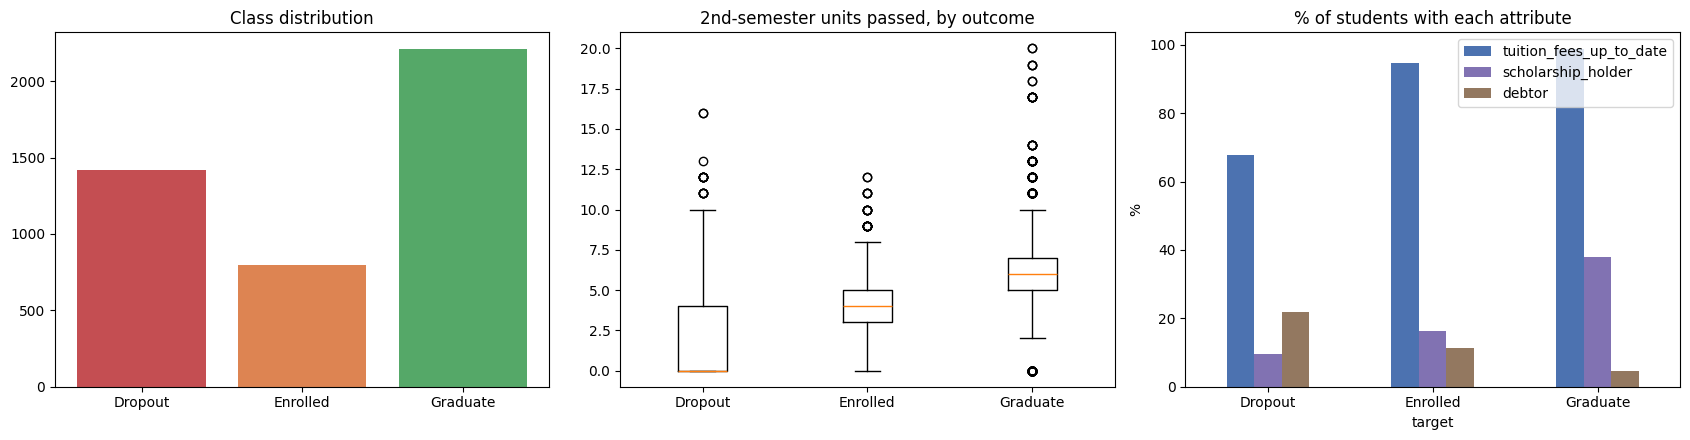

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pdf = df.select("target", "curricular_units_2nd_sem_approved", "age_at_enrollment",
                "tuition_fees_up_to_date", "scholarship_holder", "debtor").toPandas()
classes = ["Dropout", "Enrolled", "Graduate"]
colors = {"Dropout": "#C44E52", "Enrolled": "#DD8452", "Graduate": "#55A868"}

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
cnt = pdf["target"].value_counts().reindex(classes)
ax[0].bar(cnt.index, cnt.values, color=[colors[c] for c in cnt.index]); ax[0].set_title("Class distribution")

ax[1].boxplot([pdf[pdf.target == c]["curricular_units_2nd_sem_approved"] for c in classes])
ax[1].set_xticks([1, 2, 3]); ax[1].set_xticklabels(classes)
ax[1].set_title("2nd-semester units passed, by outcome")

rates = pdf.groupby("target")[["tuition_fees_up_to_date", "scholarship_holder", "debtor"]].mean().reindex(classes) * 100
rates.plot(kind="bar", ax=ax[2], rot=0, color=["#4C72B0", "#8172B2", "#937860"])
ax[2].set_title("% of students with each attribute"); ax[2].set_ylabel("%")
plt.tight_layout(); plt.show()

**Observations:** Dropouts pass far fewer 2nd-semester units, are much less likely to have their fees up to date, and are more often debtors.
The classes are imbalanced (Graduate ≈ 50%, Dropout ≈ 32%, Enrolled ≈ 18%), so we report per-class precision, recall and F1, not just accuracy.

### 3.4 Feature engineering
Two derived features capture academic **progress** better than raw counts:
- **Approval rate per semester** = units approved ÷ units enrolled (0 if no units were enrolled)
- **Grade change** = 2nd-semester grade − 1st-semester grade (a falling grade is a warning sign)

In [ ]:
def safe_ratio(num, den):
    return F.when(F.col(den) > 0, F.col(num) / F.col(den)).otherwise(F.lit(0.0))

df = (df
      .withColumn("sem1_approval_rate", safe_ratio("curricular_units_1st_sem_approved", "curricular_units_1st_sem_enrolled"))
      .withColumn("sem2_approval_rate", safe_ratio("curricular_units_2nd_sem_approved", "curricular_units_2nd_sem_enrolled"))
      .withColumn("grade_change", F.col("curricular_units_2nd_sem_grade") - F.col("curricular_units_1st_sem_grade")))

feature_cols = [c for c in df.columns if c != "target"]
print(len(feature_cols), "features used")

39 features used


### 3.5 Spark ML Pipeline
`StringIndexer` (label) → `VectorAssembler` (all features → one vector) → classifier.

Neither model needs feature scaling: trees are scale-invariant, and Gaussian NB models each feature's own mean and variance.

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier, NaiveBayes

label_indexer = StringIndexer(inputCol="target", outputCol="label", stringOrderType="alphabetAsc")  # Dropout=0, Enrolled=1, Graduate=2
assembler     = VectorAssembler(inputCols=feature_cols, outputCol="features")

dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", seed=42)
nb = NaiveBayes(featuresCol="features", labelCol="label", modelType="gaussian")

dt_pipeline = Pipeline(stages=[label_indexer, assembler, dt])
nb_pipeline = Pipeline(stages=[label_indexer, assembler, nb])

train, test = df.randomSplit([0.8, 0.2], seed=42)
train.cache(); test.cache()
print("Training students:", train.count(), "| Test students:", test.count())

Training students: 3581 | Test students: 843


### 3.6 Hyperparameter tuning of the Decision Tree (5-fold Cross Validation)

In [ ]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

f1_eval = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

grid = (ParamGridBuilder()
        .addGrid(dt.maxDepth, [3, 5, 7, 10])
        .addGrid(dt.minInstancesPerNode, [1, 20])
        .addGrid(dt.impurity, ["gini", "entropy"])
        .build())

cv = CrossValidator(estimator=dt_pipeline, estimatorParamMaps=grid, evaluator=f1_eval,
                    numFolds=5, seed=42, parallelism=4)

import time
t0 = time.time(); cv_model = cv.fit(train); dt_time = time.time() - t0

res = sorted(zip(cv_model.avgMetrics, grid), key=lambda x: -x[0])[:5]
print("Top 5 parameter combinations (mean CV weighted-F1):")
for score, p in res:
    print({k.name: v for k, v in p.items()}, "->", round(score, 4))

dt_model = cv_model.bestModel
best_tree = dt_model.stages[-1]
print(f"\nBest tree: depth={best_tree.getMaxDepth()}, minInstancesPerNode={best_tree.getMinInstancesPerNode()}, "
      f"impurity={best_tree.getImpurity()}, nodes={best_tree.numNodes}  (CV time {dt_time:.1f}s)")

Top 5 parameter combinations (mean CV weighted-F1):
{'maxDepth': 5, 'minInstancesPerNode': 1, 'impurity': 'gini'} -> 0.7502
{'maxDepth': 5, 'minInstancesPerNode': 20, 'impurity': 'gini'} -> 0.7484
{'maxDepth': 5, 'minInstancesPerNode': 1, 'impurity': 'entropy'} -> 0.7477
{'maxDepth': 5, 'minInstancesPerNode': 20, 'impurity': 'entropy'} -> 0.7471
{'maxDepth': 7, 'minInstancesPerNode': 20, 'impurity': 'entropy'} -> 0.7425

Best tree: depth=5, minInstancesPerNode=1, impurity=gini, nodes=51  (CV time 129.8s)


In [ ]:
t0 = time.time(); nb_model = nb_pipeline.fit(train); nb_time = time.time() - t0
print(f"Gaussian Naive Bayes trained in {nb_time:.2f}s")

dt_pred = dt_model.transform(test)
nb_pred = nb_model.transform(test)
labels = dt_model.stages[0].labels
print("Label mapping:", dict(enumerate(labels)))

Gaussian Naive Bayes trained in 1.03s
Label mapping: {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}


## 4. Results

In [ ]:
def evaluate(pred, name):
    ev = lambda m: MulticlassClassificationEvaluator(labelCol="label", metricName=m).evaluate(pred)
    row = {"Model": name, "Accuracy": ev("accuracy"), "Weighted F1": ev("f1"),
           "Weighted Precision": ev("weightedPrecision"), "Weighted Recall": ev("weightedRecall")}
    cm = (pred.groupBy("label", "prediction").count().toPandas()
              .pivot(index="label", columns="prediction", values="count")
              .reindex(index=range(3), columns=range(3)).fillna(0).astype(int).values)
    for i, c in enumerate(labels):
        p = cm[i, i] / cm[:, i].sum() if cm[:, i].sum() else 0
        r = cm[i, i] / cm[i, :].sum() if cm[i, :].sum() else 0
        row[f"{c} Recall"] = r
        row[f"{c} F1"] = 2 * p * r / (p + r) if (p + r) else 0
    return row, cm

r_dt, cm_dt = evaluate(dt_pred, "Decision Tree (tuned)")
r_nb, cm_nb = evaluate(nb_pred, "Gaussian Naive Bayes")
results = pd.DataFrame([r_dt, r_nb]).set_index("Model").round(4)
results.T

Model,Decision Tree (tuned),Gaussian Naive Bayes
Accuracy,0.7307,0.6940
Weighted F1,0.7254,0.6880
Weighted Precision,0.7292,0.6942
Weighted Recall,0.7307,0.6940
Dropout Recall,0.6630,0.6044
Dropout F1,0.7328,0.6832
Enrolled Recall,0.3803,0.3380
Enrolled F1,0.3927,0.3441
Graduate Recall,0.8902,0.8692
Graduate F1,0.8310,0.8052


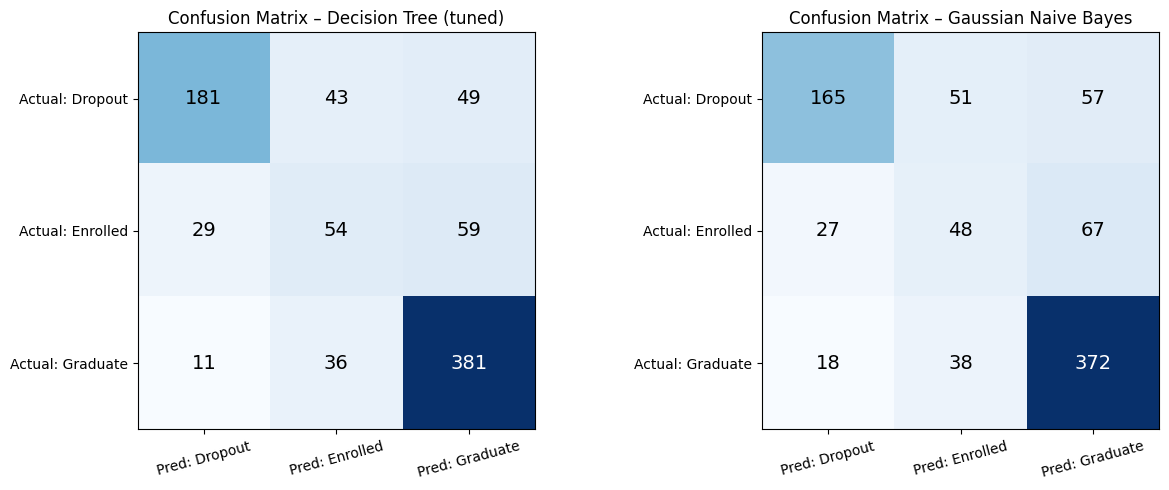

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cm, title in [(axes[0], cm_dt, "Decision Tree (tuned)"), (axes[1], cm_nb, "Gaussian Naive Bayes")]:
    ax.imshow(cm, cmap="Blues")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks(range(3)); ax.set_xticklabels([f"Pred: {l}" for l in labels], rotation=15)
    ax.set_yticks(range(3)); ax.set_yticklabels([f"Actual: {l}" for l in labels])
    ax.set_title(f"Confusion Matrix – {title}")
plt.tight_layout(); plt.show()

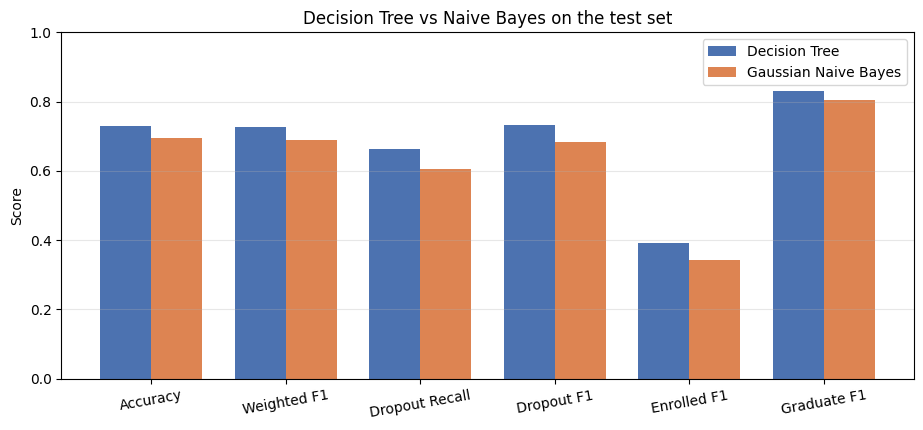

In [ ]:
metrics = ["Accuracy", "Weighted F1", "Dropout Recall", "Dropout F1", "Enrolled F1", "Graduate F1"]
x = np.arange(len(metrics)); w = 0.38
plt.figure(figsize=(11, 4.5))
plt.bar(x - w/2, results.iloc[0][metrics], w, label="Decision Tree", color="#4C72B0")
plt.bar(x + w/2, results.iloc[1][metrics], w, label="Gaussian Naive Bayes", color="#DD8452")
plt.xticks(x, metrics, rotation=10); plt.ylim(0, 1); plt.ylabel("Score")
plt.title("Decision Tree vs Naive Bayes on the test set"); plt.legend(); plt.grid(axis="y", alpha=0.3); plt.show()

### 4.1 What drives dropout? – Feature importance

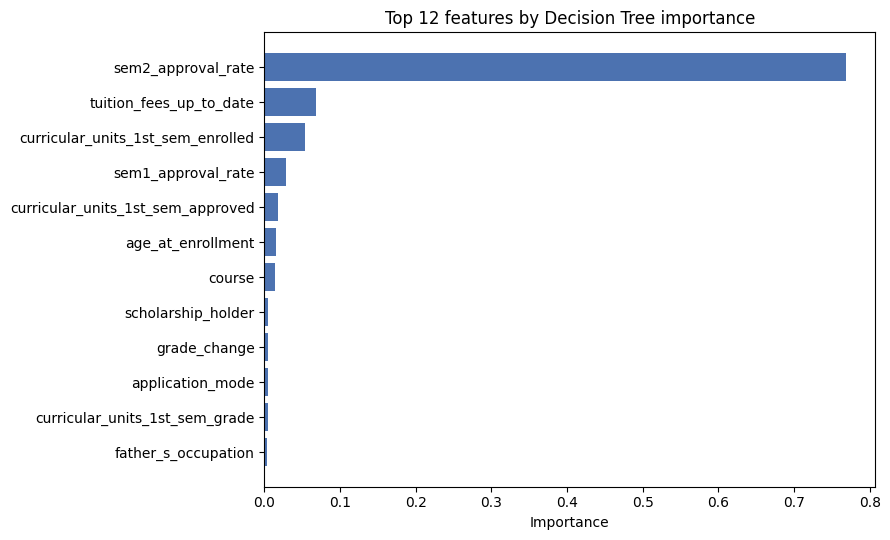

,0
sem2_approval_rate,0.7685
tuition_fees_up_to_date,0.0684
curricular_units_1st_sem_enrolled,0.0536
sem1_approval_rate,0.0290
curricular_units_1st_sem_approved,0.0178
age_at_enrollment,0.0147
course,0.0137
scholarship_holder,0.0052
grade_change,0.0047
application_mode,0.0041


In [ ]:
imp = pd.Series(best_tree.featureImportances.toArray(), index=feature_cols).sort_values(ascending=False)
top = imp.head(12)
plt.figure(figsize=(9, 5.5))
plt.barh(top.index[::-1], top.values[::-1], color="#4C72B0")
plt.title("Top 12 features by Decision Tree importance"); plt.xlabel("Importance"); plt.tight_layout(); plt.show()
top.round(4)

### 4.2 Readable rules from the tree (first levels)

In [ ]:
rules = best_tree.toDebugString
for i, name in enumerate(feature_cols):                # replace "feature 23" with real column names
    rules = re.sub(rf"feature {i}(?!\d)", name, rules)
for i, name in enumerate(labels):
    rules = rules.replace(f"Predict: {float(i)}", f"Predict: {name}")
print("\n".join(rules.splitlines()[:40]))

DecisionTreeClassificationModel: uid=DecisionTreeClassifier_100a95a02273, depth=5, numNodes=51, numClasses=3, numFeatures=39
  If (sem2_approval_rate <= 0.7928571428571429)
   If (sem2_approval_rate <= 0.225)
    If (curricular_units_1st_sem_enrolled <= 0.5)
     If (tuition_fees_up_to_date <= 0.5)
      If (inflation_rate <= 3.25)
       Predict: Dropout
      Else (inflation_rate > 3.25)
       Predict: Graduate
     Else (tuition_fees_up_to_date > 0.5)
      If (application_mode <= 16.5)
       Predict: Graduate
      Else (application_mode > 16.5)
       Predict: Dropout
    Else (curricular_units_1st_sem_enrolled > 0.5)
     Predict: Dropout
   Else (sem2_approval_rate > 0.225)
    If (tuition_fees_up_to_date <= 0.5)
     If (admission_grade <= 129.95)
      If (mother_s_occupation <= 110.5)
       Predict: Dropout
      Else (mother_s_occupation > 110.5)
       Predict: Enrolled
     Else (admission_grade > 129.95)
      Predict: Dropout
    Else (tuition_fees_up_to_date > 0.5)
 

### 4.3 Early-warning list – test students with the highest predicted dropout risk

In [ ]:
risk = F.udf(lambda v: float(v[0]), "double")      # probability of class 0 = Dropout
(dt_pred.withColumn("dropout_risk", F.round(risk("probability"), 3))
        .select("target", "dropout_risk", "curricular_units_2nd_sem_approved",
                "sem2_approval_rate", "tuition_fees_up_to_date", "debtor", "scholarship_holder")
        .orderBy(F.desc("dropout_risk"))
        .show(10))

+--------+------------+---------------------------------+------------------+-----------------------+------+------------------+
|  target|dropout_risk|curricular_units_2nd_sem_approved|sem2_approval_rate|tuition_fees_up_to_date|debtor|scholarship_holder|
+--------+------------+---------------------------------+------------------+-----------------------+------+------------------+
| Dropout|         1.0|                                5|0.8333333333333334|                      0|     0|                 0|
| Dropout|         1.0|                                6|               1.0|                      0|     1|                 0|
| Dropout|         1.0|                                5|0.8333333333333334|                      0|     0|                 0|
| Dropout|       0.949|                                2|0.3333333333333333|                      0|     1|                 0|
| Dropout|       0.949|                                3|               0.5|                      0|     1|    

## 5. Inference
*(Check these statements against the numbers produced above and adjust them to match your run.)*

1. **The Decision Tree outperforms Gaussian Naïve Bayes** in accuracy and weighted F1, and especially in recall on the **Dropout** class, which is the class that matters most for an early-warning system.
   NB's independence assumption is violated here: 1st-semester and 2nd-semester performance are strongly correlated, so NB effectively double-counts that evidence.
2. **Academic progress is the strongest predictor.** Units approved and the approval rate in the 2nd (and 1st) semester dominate the feature importances. A student who passes few units in the first year is at very high risk.
3. **Financial factors matter.** Whether *tuition fees are up to date*, *debtor* status and *scholarship* status appear high in the importance list, which suggests financial support could prevent many dropouts.
4. **"Enrolled" is the hardest class** (lowest F1). These students are in between: academically weaker than graduates but still continuing. They are often confused with the other two classes, which is reasonable, since their final outcome is genuinely uncertain.
5. **Practical use:** the university can run this model at the end of the first year, generate the ranked *early-warning list* (Section 4.3), and assign mentors or fee assistance to the top-risk students. The tree's IF–THEN rules explain to counsellors *why* each student was flagged.
6. **Limitations:** the dataset comes from a single institution, so the model must be retrained before use elsewhere. Single trees can also be unstable, and an ensemble such as a Random Forest could improve accuracy at the cost of interpretability.

## 6. URL of Implementation
Share this notebook from Colab (**Share → Anyone with the link → Viewer**) and paste the link here and in the document:

`https://colab.research.google.com/drive/<your-notebook-id>`